# JOINT FITTING BETWEEN FERMI, VERITAS (IN GAMMAPY) AND HAWC FOR A POINT SOURCE WITH POWER LAW SPECTRUM USING CRAB DATA

Anjana Kaushik Talluri

Note: The code below relies on J. Michael's model converter 

# Import packages

In [1]:
import warnings

warnings.simplefilter("ignore")
import numpy as np

np.seterr(all="ignore")



import matplotlib.pyplot as plt

import astropy.units as u
from threeML import *
from threeML.io.package_data import get_path_of_data_file



import warnings

warnings.simplefilter("ignore")
import numpy as np

np.seterr(all="ignore")
import shutil
from IPython.display import Image, display
import glob
from pathlib import Path
import matplotlib as mpl
from matplotlib import pyplot as plt
from astropy.io import fits as pyfits
import scipy as sp


from threeML import *




10:42:13 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=928360;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=687467;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/astromodels/functions/functions_1D/functions.py#50\50]8;;\
                  available                                                                                        

         WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=15464;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=865451;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/astromodels/functions/functions_1D/functions.py#71\71]8;;\
                  will not be available.                                                                           

         WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=510814;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=802921;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/astromodels/functions/functions_1D/absorption.py#36\36]8;;\
                  available                                                                                        

10:42:14 INFO      Starting 3ML!                                                                     ]8;id=701420;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=466593;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/__init__.py#31\31]8;;\

         WARNING   ROOT minimizer not available                                                ]8;id=639603;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/minimizer/minimization.py\minimization.py]8;;\:]8;id=988558;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/minimizer/minimization.py#1345\1345]8;;\

...

10:42:14 WARNING   The cthreeML package is not installed. You will not be able to use plugins which  ]8;id=740628;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=567592;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/__init__.py#79\79]8;;\
                  require the C/C++ interface (currently HAWC)                                                     

         WARNING   Could not import plugin HAWCLike.py. Do you have the relative instrument         ]8;id=921669;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=189501;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/__init__.py#129\129]8;;\
                  software installed and configured?                                                               

         WARNING   Env. variable OMP_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=303473;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=391290;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/__init__.py#341\341]8;;\
                  performances in 3ML                                                                              

10:42:15 WARNING   Env. variable MKL_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=377433;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=205809;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/__init__.py#341\341]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable NUMEXPR_NUM_THREADS is not set. Please set it to 1 for optimal     ]8;id=641391;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=167999;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/__init__.py#341\341]8;;\
                  performances in 3ML                                                                              

In [11]:
from astromodels import Powerlaw
from model_converter import SpectralModelGenerator
import astropy.units as u
import numpy as np

# Define a common model of a point source with a power law spectrum for all instruments for Crab

In [12]:
spectrum = Powerlaw()
source = PointSource("crab", ra=83.63, dec=22.01 , spectral_shape=spectrum)

spectrum.piv = 1 * u.TeV
spectrum.piv.fix = True
spectrum.piv.unit = u.TeV

spectrum.K = 3.37e-11 / (u.TeV * u.cm**2 * u.s)  # norm (in 1/(TeV cm2 s))
spectrum.K.unit = 1 / (u.TeV * u.cm**2 * u.s)

#spectrum.K.fix = True

#spectrum.K.min_value = 1e-12 / (u.TeV * u.cm**2 * u.s)
#spectrum.K.max_value = 1e-10 / (u.TeV * u.cm**2 * u.s)

spectrum.index = -2.53

#testing a bunch of things
#smg = SpectralModelGenerator(spectrum)
#gpy_p = smg.class_def()

In [13]:

f_model = Model(source)
f_model.display()
#ene = np.array([1,10,100])



Model summary:
==============

                  N
Point sources     1
Extended sources  0
Particle sources  0

Free parameters (2):
--------------------

                                  value min_value max_value            unit
crab.spectrum.main.Powerlaw.K       0.0       0.0    1000.0  TeV-1 s-1 cm-2
crab.spectrum.main.Powerlaw.index -2.53     -10.0      10.0                

Fixed parameters (3):
(abridged. Use complete=True to see all fixed parameters)


Properties (0):
--------------------

(none)


Linked parameters (0):
----------------------

(none)

Independent variables:
----------------------

(none)

Linked functions (0):
----------------------

(none)

# VERITAS

In [14]:
import model_converter

from GammapyLike import GammapyLike

In [15]:
VERITAS = GammapyLike("VERITAS", config_file="config.yaml")

In [16]:
veritas_data = DataList(VERITAS)

# FERMI

In [17]:
lat_catalog = FermiLATSourceCatalog()

ra, dec, table = lat_catalog.search_around_source("Crab", radius=0.004)

table

Trying https://heasarc.gsfc.nasa.gov/cgi-bin/vo/cone/coneGet.pl?table=fermilpsc&


name,source_type,short_source_type,ra,dec,assoc_name,tevcat_assoc,Search_Offset
,,,deg,deg,,,
object,str32,object,float64,float64,object,object,float64
4FGL J0534.5+2200,"pulsar, identified by pulsations",PSR,83.6367,22.0149,PSR J0534+2200,Crab pulsar,0.2119


In [18]:
model = lat_catalog.get_model()

In [19]:
model.free_point_sources_within_radius(3.0, normalization_only=True)

model.display()

Model summary:
==============

                  N
Point sources     1
Extended sources  0
Particle sources  0

Free parameters (1):
--------------------

                   value min_value max_value            unit
PSR_J0534p2200...K   0.0       0.0       0.0  keV-1 s-1 cm-2

Fixed parameters (6):
(abridged. Use complete=True to see all fixed parameters)


Properties (0):
--------------------

(none)


Linked parameters (0):
----------------------

(none)

Independent variables:
----------------------

(none)

Linked functions (0):
----------------------

(none)

In [20]:
ra = 83.63
dec = 22.01

In [21]:
# Download data from Jan 01 2010 to February 1 2010

tstart = "2010-01-01 00:00:00"
tstop = "2010-02-01 00:00:00"

# Note that this will understand if you already download these files, and will
# not do it twice unless you change your selection or the outdir

evfile, scfile = download_LAT_data(
    ra,
    dec,
    20.0,
    tstart,
    tstop,
    time_type="Gregorian",
    destination_directory="Crab_data",
)

07:59:57 INFO      Query parameters:                                                       ]8;id=339635;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py\download_LAT_data.py]8;;\:]8;id=215381;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py#262\262]8;;\

         INFO                          coordfield = 83.6300,22.0100                        ]8;id=956015;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py\download_LAT_data.py]8;;\:]8;id=869973;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py#266\266]8;;\

         INFO                         coordsystem = J2000                                  ]8;id=363159;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py\download_LAT_data.py]8;;\:]8;id=715693;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py#266\266]8;;\

         INFO                          shapefield = 20.0                                   ]8;id=807260;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py\download_LAT_data.py]8;;\:]8;id=600841;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py#266\266]8;;\

         INFO                           timefield = 2010-01-01 00:00:00,2010-02-01         ]8;id=16824;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py\download_LAT_data.py]8;;\:]8;id=650027;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py#266\266]8;;\
                  00:00:00                                                                                         

...

         INFO                         energyfield = 30.000,1000000.000                     ]8;id=979674;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py\download_LAT_data.py]8;;\:]8;id=543799;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py#266\266]8;;\

         INFO              photonOrExtendedOrNone = Photon                                 ]8;id=284018;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py\download_LAT_data.py]8;;\:]8;id=59233;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py#266\266]8;;\

         INFO                         destination = query                                  ]8;id=377502;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py\download_LAT_data.py]8;;\:]8;id=886371;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py#266\266]8;;\

         INFO                          spacecraft = checked                                ]8;id=172650;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py\download_LAT_data.py]8;;\:]8;id=431222;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py#266\266]8;;\

         INFO      Query ID: e94fe495b65679baa926097eebf7f7fd                              ]8;id=649284;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py\download_LAT_data.py]8;;\:]8;id=217525;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py#271\271]8;;\

In [22]:
import fermipy

In [23]:
config = FermipyLike.get_basic_config(
    evfile=evfile,
    scfile=scfile,
    ra=ra,
    dec=dec,
    fermipy_verbosity=1,
    fermitools_chatter=0,
)

# See what we just got

config.display()

binning:
  binsperdec: 8
  binsz: 0.1
  roiwidth: 10.0
data:
  evfile: /Users/anjanaktelidevara/Desktop/VERITAS/Internship/gammapy-plugin/gammapy_plugin/Crab_data/Le94fe495b65679baa926097eebf7f7fd_FT1.fits
  scfile: /Users/anjanaktelidevara/Desktop/VERITAS/Internship/gammapy-plugin/gammapy_plugin/Crab_data/L220812144453F357373F65_SC00.fits
logging:
  chatter: 0
  verbosity: 1
selection:
  dec: 22.01
  emax: 100000.0
  emin: 100.0
  evclass: 128
  evtype: 3
  filter: DATA_QUAL>0 && LAT_CONFIG==1
  ra: 83.63
  tmax: 286675202.0
  tmin: 283996802.0
  zmax: 100.0



binning:
 binsperdec: 8
 binsz: 0.1
 roiwidth: 10.0
data:
 evfile: /Users/anjanaktelidevara/Desktop/VERITAS/Internship/gammapy-plugin/gammapy_plugin/Crab_data/Le94fe495b65679baa926097eebf7f7fd_FT1.fits
 scfile: /Users/anjanaktelidevara/Desktop/VERITAS/Internship/gammapy-plugin/gammapy_plugin/Crab_data/L220812144453F357373F65_SC00.fits
logging:
 chatter: 0
 verbosity: 1
selection:
 dec: 22.01
 emax: 100000.0
 emin: 100.0
 evclass: 128
 evtype: 3
 filter: DATA_QUAL>0 && LAT_CONFIG==1
 ra: 83.63
 tmax: 286675202.0
 tmin: 283996802.0
 zmax: 100.0

In [24]:
LAT = FermipyLike("LAT", config)
config.display()

binning:
  binsperdec: 8
  binsz: 0.1
  roiwidth: 10.0
data:
  evfile: /Users/anjanaktelidevara/Desktop/VERITAS/Internship/gammapy-plugin/gammapy_plugin/Crab_data/Le94fe495b65679baa926097eebf7f7fd_FT1.fits
  scfile: /Users/anjanaktelidevara/Desktop/VERITAS/Internship/gammapy-plugin/gammapy_plugin/Crab_data/L220812144453F357373F65_SC00.fits
fileio:
  outdir: __001f42fcf467f6472a624190907310b5
logging:
  chatter: 0
  verbosity: 1
selection:
  dec: 22.01
  emax: 100000.0
  emin: 100.0
  evclass: 128
  evtype: 3
  filter: DATA_QUAL>0 && LAT_CONFIG==1
  ra: 83.63
  tmax: 286675202.0
  tmin: 283996802.0
  zmax: 100.0



binning:
 binsperdec: 8
 binsz: 0.1
 roiwidth: 10.0
data:
 evfile: /Users/anjanaktelidevara/Desktop/VERITAS/Internship/gammapy-plugin/gammapy_plugin/Crab_data/Le94fe495b65679baa926097eebf7f7fd_FT1.fits
 scfile: /Users/anjanaktelidevara/Desktop/VERITAS/Internship/gammapy-plugin/gammapy_plugin/Crab_data/L220812144453F357373F65_SC00.fits
fileio:
 outdir: __001f42fcf467f6472a624190907310b5
logging:
 chatter: 0
 verbosity: 1
selection:
 dec: 22.01
 emax: 100000.0
 emin: 100.0
 evclass: 128
 evtype: 3
 filter: DATA_QUAL>0 && LAT_CONFIG==1
 ra: 83.63
 tmax: 286675202.0
 tmin: 283996802.0
 zmax: 100.0

# HAWC

In [1]:
from hawc_hal import HAL, HealpixConeROI

import os

os.environ['OMP_NUM_THREADS'] = "1"
os.environ['MKL_NUM_THREADS'] = "1"

10:55:05 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=87685;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=302545;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/astromodels/functions/functions_1D/functions.py#50\50]8;;\
                  available                                                                                        

         WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=906;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=501882;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/astromodels/functions/functions_1D/functions.py#71\71]8;;\
                  will not be available.                                                                           

         WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=294888;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=570827;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/astromodels/functions/functions_1D/absorption.py#36\36]8;;\
                  available                                                                                        

10:55:05 INFO      Starting 3ML!                                                                     ]8;id=631177;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=696452;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/__init__.py#31\31]8;;\

         WARNING   ROOT minimizer not available                                                ]8;id=834385;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/minimizer/minimization.py\minimization.py]8;;\:]8;id=105439;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/minimizer/minimization.py#1345\1345]8;;\

...

10:55:06 WARNING   The cthreeML package is not installed. You will not be able to use plugins which  ]8;id=745866;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=68328;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/__init__.py#79\79]8;;\
                  require the C/C++ interface (currently HAWC)                                                     

         WARNING   Could not import plugin HAWCLike.py. Do you have the relative instrument         ]8;id=126123;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=361788;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/__init__.py#129\129]8;;\
                  software installed and configured?                                                               

         WARNING   Env. variable OMP_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=249975;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=721504;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/__init__.py#341\341]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable MKL_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=742583;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=23545;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/__init__.py#341\341]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable NUMEXPR_NUM_THREADS is not set. Please set it to 1 for optimal     ]8;id=658367;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=106252;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/__init__.py#341\341]8;;\
                  performances in 3ML                                                                              

In [3]:
import requests
import shutil
import os


def get_hawc_file(filename, odir="./", overwrite=False):

    if overwrite or not os.path.exists(odir + filename):
        url = "https://data.hawc-observatory.org/datasets/crab_data/public_data/crab_2017/"

        req = requests.get(url + filename, verify=False, stream=True)
        req.raw.decode_content = True
        with open(odir + filename, "wb") as f:
            shutil.copyfileobj(req.raw, f)

    return odir + filename


maptree = "HAWC_9bin_507days_crab_data.hd5"
response = "HAWC_9bin_507days_crab_response.hd5"
odir = "./"


maptree = get_hawc_file(maptree, odir)
response = get_hawc_file(response, odir)

assert os.path.exists(maptree)
assert os.path.exists(response)



WARNING InsecureRequestWarning: Unverified HTTPS request is being made to host 'data.hawc-observatory.org'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/1.26.x/advanced-usage.html#ssl-warnings


WARNING InsecureRequestWarning: Unverified HTTPS request is being made to host 'data.hawc-observatory.org'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/1.26.x/advanced-usage.html#ssl-warnings



In [29]:
%%capture
from hawc_hal import HAL, HealpixConeROI
import matplotlib.pyplot as plt
from threeML import *

silence_warnings()
%matplotlib inline



# Define the ROI.
ra_crab, dec_crab = 83.63, 22.02
data_radius = 3.0  # in degree
model_radius = 3.0  # in degree

roi = HealpixConeROI(
    data_radius=data_radius, model_radius=model_radius, ra=ra_crab, dec=dec_crab
)

# Instance the plugin
hawc = HAL("HAWC", maptree, response, roi, flat_sky_pixels_size=0.1)

# Use from bin 1 to bin 9
hawc.set_active_measurements(1, 9)

In [30]:
hawc.display()

08:02:18 INFO      Region of Interest:                                                                   ]8;id=241501;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/hawc_hal/HAL.py\HAL.py]8;;\:]8;id=680747;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/hawc_hal/HAL.py#270\270]8;;\

         INFO      -------------------                                                                   ]8;id=603175;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/hawc_hal/HAL.py\HAL.py]8;;\:]8;id=804387;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/hawc_hal/HAL.py#271\271]8;;\

         INFO      HealpixConeROI: Center (R.A., Dec) = (83.630, 22.020), data radius =      ]8;id=330639;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/hawc_hal/region_of_interest/healpix_cone_roi.py\healpix_cone_roi.py]8;;\:]8;id=374070;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/hawc_hal/region_of_interest/healpix_cone_roi.py#87\87]8;;\
                  3.000 deg, model radius: 3.000 deg                                                               

         INFO                                                                                            ]8;id=814422;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/hawc_hal/HAL.py\HAL.py]8;;\:]8;id=476839;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/hawc_hal/HAL.py#274\274]8;;\

         INFO      Flat sky projection:                                                                  ]8;id=564901;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/hawc_hal/HAL.py\HAL.py]8;;\:]8;id=888540;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/hawc_hal/HAL.py#275\275]8;;\

...

         INFO      Total data size: 1.38 Mb                                                         ]8;id=455212;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/hawc_hal/maptree/map_tree.py\map_tree.py]8;;\:]8;id=526629;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/hawc_hal/maptree/map_tree.py#151\151]8;;\

         INFO                                                                                            ]8;id=479944;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/hawc_hal/HAL.py\HAL.py]8;;\:]8;id=574760;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/hawc_hal/HAL.py#294\294]8;;\

         INFO      Active energy/nHit planes (9):                                                        ]8;id=205602;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/hawc_hal/HAL.py\HAL.py]8;;\:]8;id=519739;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/hawc_hal/HAL.py#295\295]8;;\

         INFO      -------------------------------                                                       ]8;id=78800;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/hawc_hal/HAL.py\HAL.py]8;;\:]8;id=612016;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/hawc_hal/HAL.py#296\296]8;;\

         INFO      ['1', '2', '3', '4', '5', '6', '7', '8', '9']                                         ]8;id=703531;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/hawc_hal/HAL.py\HAL.py]8;;\:]8;id=124202;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/hawc_hal/HAL.py#297\297]8;;\

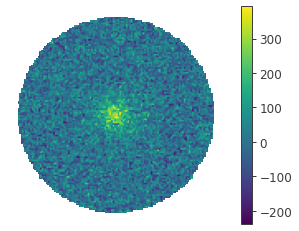

In [31]:
fig = hawc.display_stacked_image(smoothing_kernel_sigma=0.01)

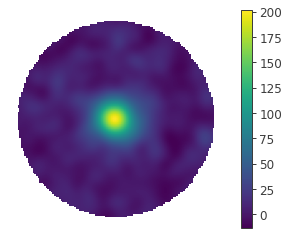

In [32]:
fig_smooth = hawc.display_stacked_image(smoothing_kernel_sigma=0.2)

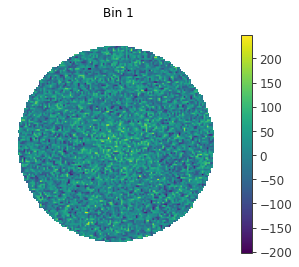

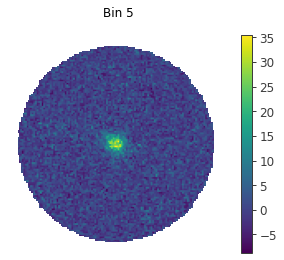

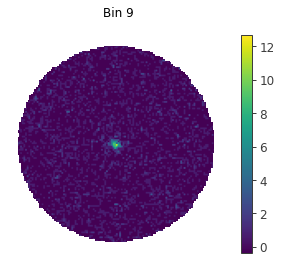

In [33]:
for bin in [1, 5, 9]:

    # set only one active bin
    hawc.set_active_measurements(bin, bin)

    fig = hawc.display_stacked_image(smoothing_kernel_sigma=0.01)
    fig.suptitle("Bin {}".format(bin))

# Joint likelihood fit

In [34]:
data = DataList(VERITAS, LAT, hawc)

jl = JointLikelihood(f_model, data)
f_model.display()

08:02:46 INFO      Using IRFs P8R3_SOURCE_V3                                                     ]8;id=293031;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/plugins/FermipyLike.py\FermipyLike.py]8;;\:]8;id=803655;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/plugins/FermipyLike.py#105\105]8;;\


Found Galactic template for IRF. P8R3_SOURCE_V3: /opt/anaconda3/envs/fermipy/share/fermitools/refdata/fermi/galdiffuse/gll_iem_v07.fits

Cutting the template around the ROI: 


Found Isotropic template for irf P8R3_SOURCE_V3: /opt/anaconda3/envs/fermipy/share/fermitools/refdata/fermi/galdiffuse/iso_P8R3_SOURCE_V3_v1.txt


the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
Set MJD-OBS to 55197.000000 from DATE-OBS.
Set MJD-END to 55227.982165 from DATE-END'. [astropy.wcs.wcs]


08:03:03 INFO      set the minimizer to minuit                                             ]8;id=383560;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=600217;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/classicMLE/joint_likelihood.py#1042\1042]8;;\

Model summary:
==============

                  N
Point sources     1
Extended sources  0
Particle sources  0

Free parameters (2):
--------------------

                                  value min_value max_value            unit
crab.spectrum.main.Powerlaw.K       0.0       0.0    1000.0  TeV-1 s-1 cm-2
crab.spectrum.main.Powerlaw.index -2.53     -10.0      10.0                

Fixed parameters (4):
(abridged. Use complete=True to see all fixed parameters)


Properties (0):
--------------------

(none)


Linked parameters (0):
----------------------

(none)

Independent variables:
----------------------

(none)

Linked functions (0):
----------------------

(none)

In [35]:
res = jl.fit()



Best fit values:



,result,unit
parameter,,
crab.spectrum.main.Powerlaw.K,(1.72 +/- 0.09) x 10^-8,1 / (cm2 keV s)
crab.spectrum.main.Powerlaw.index,-2.3261 +/- 0.0033,



Correlation matrix:



1.00,-0.96
-0.96,1.00



Values of -log(likelihood) at the minimum:



,-log(likelihood)
HAWC,1935.005383
LAT,118091.386897
VERITAS,246.835621
total,120273.227900



Values of statistical measures:



,statistical measures
AIC,240550.455837
BIC,240571.847104


In [36]:
results = jl.results
results.write_to("crab_joint_fit.fits", overwrite=True)
results.optimized_model.save("crab_joint_fit.yml", overwrite=True)

In [37]:
results

# Some plots

Smoothing planes:   0%|          | 0/1 [00:00<?, ?it/s]

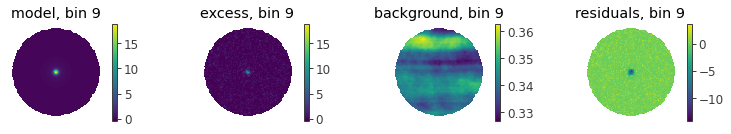

In [38]:
fig = hawc.display_fit(smoothing_kernel_sigma=0.01, display_colorbar=True)

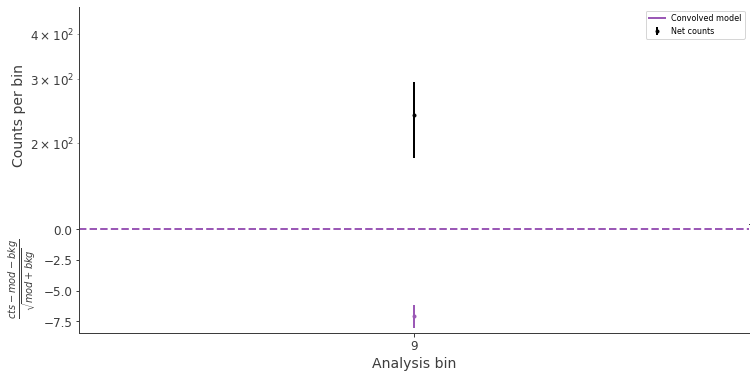

In [39]:
fig = hawc.display_spectrum()

processing MLE analyses:   0%|                            | 0/1 [00:00<?, ?it/s]

Propagating errors:   0%|                                | 0/50 [00:00<?, ?it/s]

Text(0.5, 0, 'Energy [TeV]')

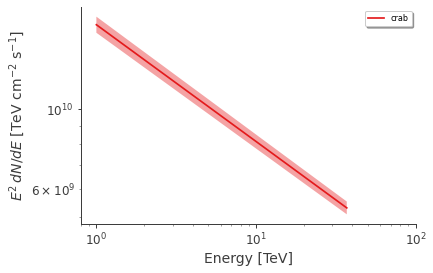

In [40]:
fig, ax = plt.subplots()

plot_spectra(
    results,
    ene_min=1.0,
    ene_max=37,
    num_ene=50,
    energy_unit="TeV",
    flux_unit="TeV/(s cm2)",
    subplot=ax,
)
ax.set_xlim(0.8, 100)
ax.set_ylabel(r"$E^2\,dN/dE$ [TeV cm$^{-2}$ s$^{-1}$]")
ax.set_xlabel("Energy [TeV]")

Profiling likelihood:   0%|                              | 0/30 [00:00<?, ?it/s]

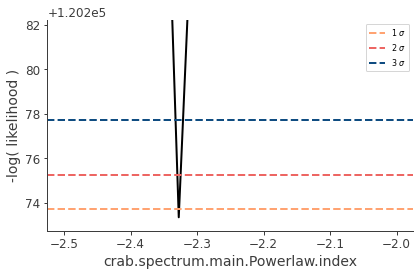

In [41]:
res = jl.get_contours(
    f_model.crab.spectrum.main.Powerlaw.index, -2.5, -2, 30
)

### Disregard the work below, just for reference

In [ ]:
# Define model
spectrum = Powerlaw()
source = PointSource("crab", ra=ra_crab, dec=dec_crab, spectral_shape=spectrum)

spectrum.piv = 7 * u.TeV
spectrum.piv.fix = True

spectrum.K = 1e-14 / (u.TeV * u.cm**2 * u.s)  # norm (in 1/(TeV cm2 s))
spectrum.K.bounds = (1e-35, 1e-10) / (
    u.TeV * u.cm**2 * u.s
)  # without units energies would be in keV

spectrum.alpha = -2.5  # log parabolic alpha (index)
spectrum.alpha.bounds = (-4.0, 2.0)

spectrum.beta = 0  # log parabolic beta (curvature)
spectrum.beta.bounds = (-1.0, 1.0)

model = Model(source)

model.display(complete=True)

In [ ]:
ra_crab, dec_crab = 83.633083, 22.014500

roi = HealpixConeROI(3.0, 12.0, ra=ra_crab, dec=dec_crab)

hawc = HAL("HAWC", 
                  "/home/giacomov/science/hawc/data/maptree_1024.root", 
                  "/home/giacomov/science/hawc/data/response.root",
                  roi)

hawc.set_active_measurements(1, 9)

hawc.display()